**Question 0:** I think that we could tokenize each known document from each author and compare the term frequency similarity to the unknown ones. 

In [1]:
import pandas as pd
import numpy as np

import requests

corpus = []

def add_paper(x):
    url = f"https://dlsun.github.io/pods/data/federalist/{x}.txt"
    text = requests.get(url).text
    corpus.append(text)

for x in range(1, 86):
    add_paper(x)


**Question 1:**

In [2]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer(max_features =50)
vec.fit(corpus)
vocab = vec.get_feature_names_out()
tf = vec.transform(corpus)
tf_df = pd.DataFrame(tf.toarray(), columns=vocab)
tf_df.head(20)

,all,an,and,any,are,as,at,be,been,but,...,them,they,this,those,to,we,which,will,with,would
0,9,11,40,6,12,10,8,34,3,2,...,2,6,14,9,72,8,18,25,6,2
1,4,1,83,1,6,16,10,15,8,8,...,4,22,14,2,53,5,11,2,13,5
2,4,3,60,5,8,24,1,31,2,7,...,8,5,6,6,56,0,11,24,10,2
3,4,3,90,5,11,20,2,26,2,10,...,12,17,1,4,51,10,10,15,12,17
4,4,4,72,3,3,3,4,31,0,4,...,11,11,6,9,45,5,10,7,11,37
5,6,12,81,0,18,19,6,18,13,5,...,3,13,11,8,61,5,24,6,15,6
6,12,15,51,7,7,19,11,47,8,3,...,12,7,22,8,82,16,24,1,12,51
7,9,13,54,2,14,16,11,35,16,10,...,11,13,19,6,80,5,26,11,13,27
8,8,13,45,4,14,19,10,26,15,6,...,5,20,15,6,71,6,25,7,14,8
9,4,14,121,4,27,20,8,61,9,11,...,8,11,11,4,100,9,39,30,11,6


**Question 2:**

In [3]:
authors = pd.read_csv("https://dlsun.github.io/pods/data/federalist/authorship.csv")
df_authors_tf = tf_df.join(authors)

In [4]:
word_totals = tf_df.sum()
top_words = word_totals.sort_values(ascending=False).head(10)
top_word_names = top_words.index.tolist()
authors_top_words = df_authors_tf[top_word_names + ["Author"]]
authors_top_words

author_word_means = (authors_top_words.groupby("Author")[top_word_names].mean().reset_index()
)

plot_data = author_word_means.melt(id_vars="Author", var_name="Word", value_name="Average_Count"
)

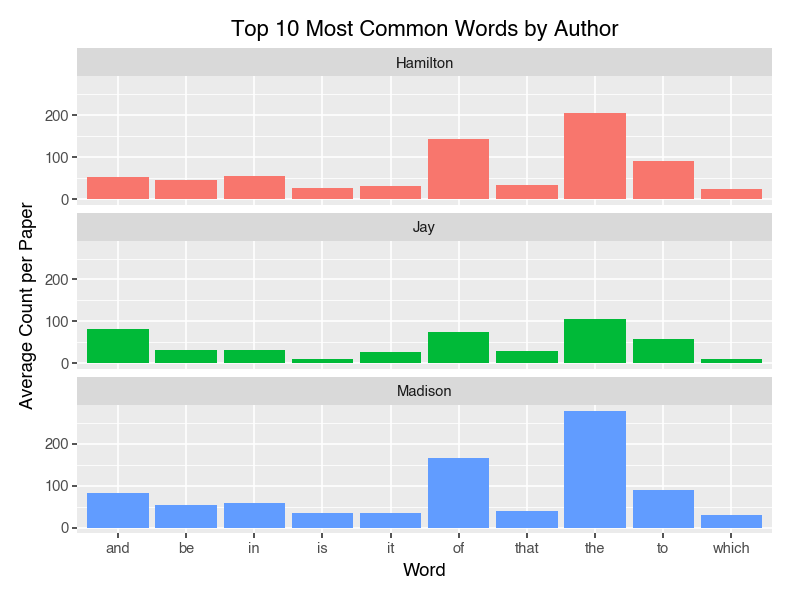

In [5]:
from plotnine import (ggplot, aes, geom_col, facet_wrap, labs)

(
    ggplot(
        plot_data,
        aes(x="Word", y="Average_Count", fill="Author")
    )
    + geom_col(show_legend=False)
    + facet_wrap("~Author", ncol=1)
    + labs(
        title="Top 10 Most Common Words by Author",
        x="Word",
        y="Average Count per Paper"
    )

)

From these graphs, it looks like “the,” “of,” and “to” are some of the most common words for all three authors. Madison seems to use “the” and “of” more than Hamilton and Jay, so papers with a lot of those words may be more likely to be Madison’s. Jay also uses “is” less often, so a paper that uses “is” a lot might be more likely to belong to Hamilton or Madison. Overall, looking at several of these word patterns together could help us make a guess about who wrote each paper.

**Question 3:**
Similar to what I was saying above, we could compare the word frequencies in each unknown paper to the patterns we saw in the papers with known authors. For example, since Madison tends to use “the” more often, an unknown paper with a high count of “the” might be more likely to be his. However, instead of relying on just one word, we could compare all 50 common words and find which known papers have the most similar overall word patterns. Then we could use the authors of those similar papers to make a prediction for each unknown paper.

**Question 4:**


In [6]:
from sklearn.metrics.pairwise import cosine_distances

known = authors["Author"].notna()
known_authors = authors.loc[known, "Author"]
tf_known = tf_df[known]

unknown_indices = authors.index[~known]

all_distances = cosine_distances(tf_df.loc[unknown_indices],tf_known
)


predicted_authors = []
for distances in all_distances:
    closest_five = np.argsort(distances)[:5]
    five_authors = known_authors.iloc[closest_five]
    prediction = five_authors.mode().iloc[0]
    predicted_authors.append(prediction)

guesses_df = authors.loc[~known, ["Paper"]].copy()
guesses_df["Predicted_Author"] = predicted_authors

guesses_df


,Paper,Predicted_Author
17,18,Madison
18,19,Madison
19,20,Madison
48,49,Hamilton
49,50,Madison
50,51,Madison
51,52,Hamilton
52,53,Madison
53,54,Madison
54,55,Hamilton


In [7]:
guesses_df_table = guesses_df.groupby("Predicted_Author")["Paper"].apply(list).reset_index()
guesses_df_table

,Predicted_Author,Paper
0,Hamilton,"[49, 52, 55, 56, 62]"
1,Madison,"[18, 19, 20, 50, 51, 53, 54, 57, 58, 63]"


Based on the criteria in Question 4, I would attribute papers 49, 52, 55, 56, and 62 to Hamilton, and papers 18, 19, 20, 50, 51, 53, 54, 57, 58, and 63 to Madison. The algorithm did not attribute any of the disputed papers to Jay.

**Question 5:**

In [8]:
from sklearn.metrics.pairwise import cosine_distances

tf_known = tf_df[known]
known_distances = cosine_distances(tf_known)
predicted_authors_known = []

for distances in known_distances:
    closest_five_known = np.argsort(distances)[1:6]
    five_authors_known = known_authors.iloc[closest_five_known]
    prediction = five_authors_known.mode().iloc[0]
    predicted_authors_known.append(prediction)

known_results = authors.loc[known, ["Paper", "Author"]].copy()
known_results = known_results.rename(columns={"Author": "Actual_Author"})
known_results["Predicted_Author"] = predicted_authors_known
known_results

,Paper,Actual_Author,Predicted_Author
0,1,Hamilton,Hamilton
1,2,Jay,Madison
2,3,Jay,Jay
3,4,Jay,Jay
4,5,Jay,Jay
...,...,...,...
80,81,Hamilton,Hamilton
81,82,Hamilton,Hamilton
82,83,Hamilton,Hamilton
83,84,Hamilton,Hamilton


**Question 6:**

In [9]:
known_results["Accurate"] = (known_results['Actual_Author'] == known_results['Predicted_Author']).astype(int)

known_results.groupby("Actual_Author")["Accurate"].mean()*100

Actual_Author
Hamilton    100.000000
Jay          60.000000
Madison      92.857143
Name: Accurate, dtype: float64

Our method correctly predicted all of the papers that were actually written by Hamilton. It also correctly predicted 92.86% of Madison’s papers, but only 60% of Jay’s papers. Overall, the method seems to work really well for Hamilton and Madison, but it has more trouble recognizing papers written by Jay.

**Question 7**

In [10]:
known_results["Accurate"] = (known_results['Predicted_Author'] == known_results['Actual_Author']).astype(int)

known_results.groupby("Predicted_Author")["Accurate"].mean()*100

Predicted_Author
Hamilton     98.076923
Jay         100.000000
Madison      86.666667
Name: Accurate, dtype: float64

Of the papers predicted to be written by Hamilton, 98.08% were actually written by Hamilton. All of the papers predicted to be written by Jay were actually written by Jay, while 86.67% of the papers predicted to be written by Madison were actually Madison’s. This shows that the method’s predictions were usually reliable, especially when it predicted Hamilton or Jay. However, even though the Jay predictions were 100% correct, the previous question showed that the method still failed to recognize some of Jay’s papers.